### punto 4

In [1]:
!pip install control

In [2]:
# Modelo del sistema y respuestas impulso/escalón
import numpy as np
import matplotlib.pyplot as plt
import control as ctrl
from control.matlab import *   # funciones estilo MATLAB

In [3]:
# Parámetros del sistema
R = 0.5
Cs = 2
Cp = 0.2

# Funciones de transferencia
# X(s) = G1(s)F(s) - G2(s)Fo(s)

# G1(s) = (Cs*Cp*R*s + Cp) / ((R*Cs + R*Cp)*s + 1)
num_G1 = [Cs*Cp*R, Cp]
den_G1 = [R*Cs + R*Cp, 1]
G1 = tf(num_G1, den_G1)

# G2(s) = (Cp) / ((R*Cs + R*Cp)*s + 1)
num_G2 = [Cp]
den_G2 = [R*Cs + R*Cp, 1]
G2 = tf(num_G2, den_G2)

print("G1(s) =", G1)
print(" ")
print("G2(s) =", G2)

G1(s) = <TransferFunction>: sys[0]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

  0.2 s + 0.2
  -----------
   1.1 s + 1
 
G2(s) = <TransferFunction>: sys[1]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

     0.2
  ---------
  1.1 s + 1


#### Respuesta al Impulso y al Escalon

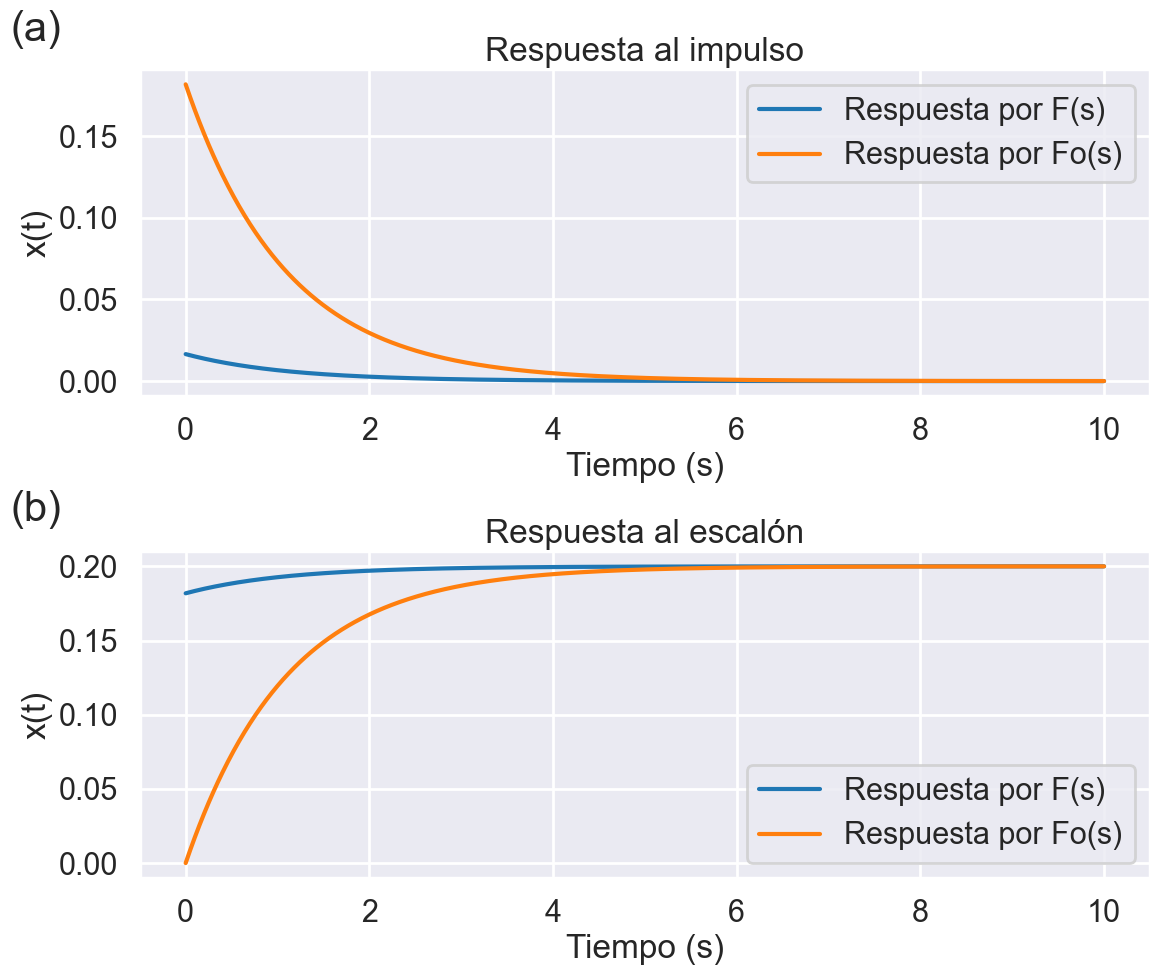

In [21]:
import seaborn as sns

t = np.linspace(0, 10, 1000)

# ===== ESTILO =====
sns.set_theme(context='poster', style='darkgrid', palette=['#1f77b4', '#ff7f0e'])

# ===== SUBPLOTS =====
fig, ax = plt.subplots(2, 1, figsize=(12, 10))

# --- IMPULSO ---
y1, t1 = impulse(G1, T=t)
y2, t2 = impulse(G2, T=t)

ax[0].plot(t1, y1, label="Respuesta por F(s)")
ax[0].plot(t2, y2, label="Respuesta por Fo(s)")
ax[0].set_title("Respuesta al impulso")
ax[0].set_xlabel("Tiempo (s)")
ax[0].set_ylabel("x(t)")
ax[0].legend()

# --- ESCALÓN ---
y1, t1 = step(G1, T=t)
y2, t2 = step(G2, T=t)

ax[1].plot(t1, y1, label="Respuesta por F(s)")
ax[1].plot(t2, y2, label="Respuesta por Fo(s)")
ax[1].set_title("Respuesta al escalón")
ax[1].set_xlabel("Tiempo (s)")
ax[1].set_ylabel("x(t)")
ax[1].legend()

# etiquetas fuera del gráfico
fig.text(0.02, 0.96, "(a)", fontsize=30)
fig.text(0.02, 0.48, "(b)", fontsize=30)

plt.tight_layout()
plt.show()

### Discretizacion del modelo mecanico 

In [5]:
# Tiempo de muestreo
Ts = 0.11

# Transformada Z (discretización)
G1z = c2d(G1, Ts, method='zoh')
G2z = c2d(G2, Ts, method='zoh')

print("\nG1(z) =")
print(G1z)

print("\nG2(z) =")
print(G2z)



G1(z) =
<TransferFunction>: sys[0]$sampled
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']
dt = 0.11

  0.1818 z - 0.1628
  -----------------
     z - 0.9048

G2(z) =
<TransferFunction>: sys[1]$sampled
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']
dt = 0.11

   0.01903
  ----------
  z - 0.9048


#### Respuest al impulso y escalon comparada con la normal

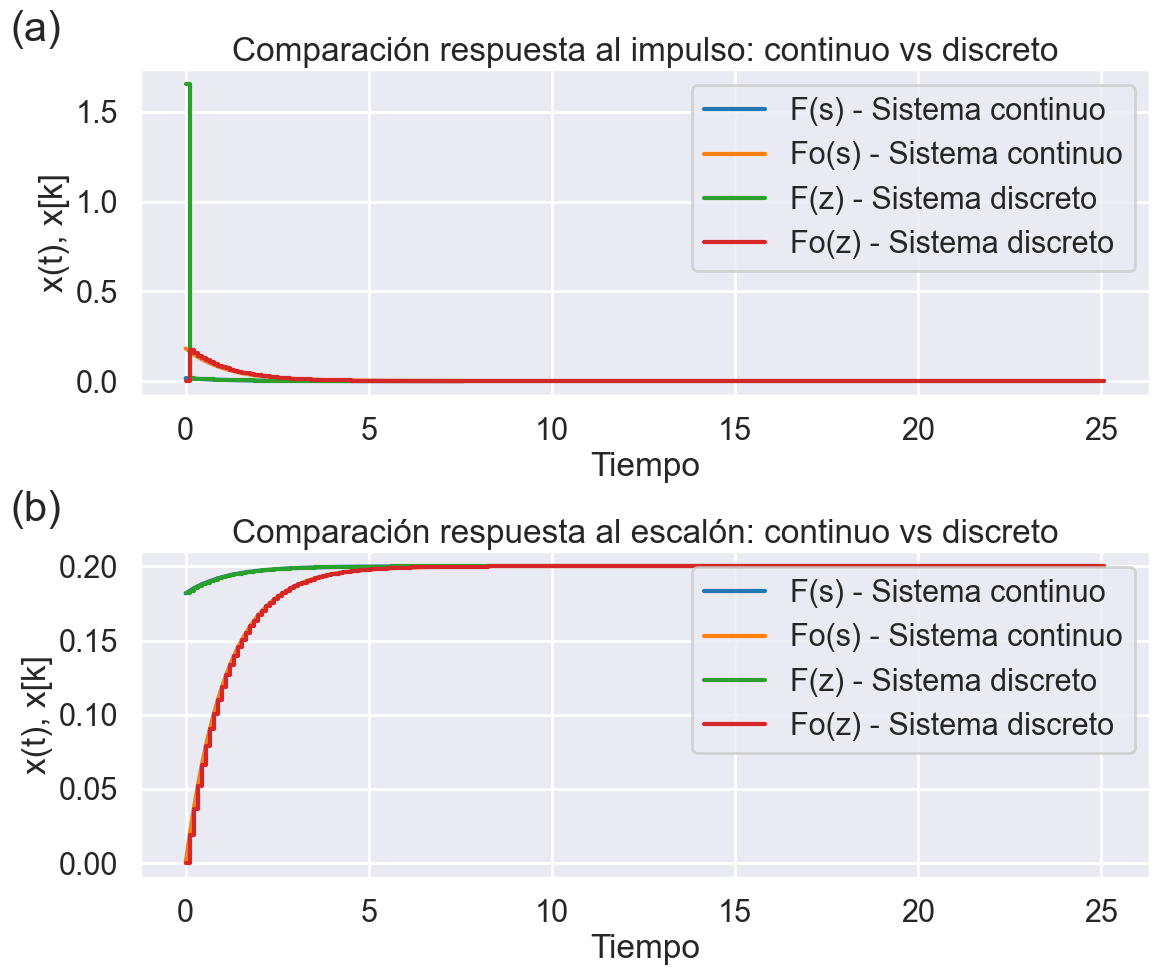

In [24]:
# ===== RESPUESTAS =====
# Impulso
t_imp_s,  y_imp_s  = ctrl.impulse_response(G1)
t2_imp_s, y2_imp_s = ctrl.impulse_response(G2)
t_imp_z,  y_imp_z  = ctrl.impulse_response(G1z)
t2_imp_z, y2_imp_z = ctrl.impulse_response(G2z)

# Escalón
t_step_s,  y_step_s  = ctrl.step_response(G1)
t2_step_s, y2_step_s = ctrl.step_response(G2)
t_step_z,  y_step_z  = ctrl.step_response(G1z)
t2_step_z, y2_step_z = ctrl.step_response(G2z)

# ===== SUBPLOTS =====
fig, ax = plt.subplots(2, 1, figsize=(12, 10))

# --- IMPULSO ---
ax[0].plot(t_imp_s,  y_imp_s,  color='#1f77b4', label="F(s) - Sistema continuo")
ax[0].plot(t2_imp_s, y2_imp_s, color='#ff7f0e', label="Fo(s) - Sistema continuo")
ax[0].step(t_imp_z,  y_imp_z,  where="post", color='#2ca02c', label="F(z) - Sistema discreto")
ax[0].step(t2_imp_z, y2_imp_z, where="post", color='#d62728', label="Fo(z) - Sistema discreto")
ax[0].set_title("Comparación respuesta al impulso: continuo vs discreto")
ax[0].set_xlabel("Tiempo")
ax[0].set_ylabel("x(t), x[k]")
ax[0].legend()

# --- ESCALÓN ---
ax[1].plot(t_step_s,  y_step_s,  color='#1f77b4', label="F(s) - Sistema continuo")
ax[1].plot(t2_step_s, y2_step_s, color='#ff7f0e', label="Fo(s) - Sistema continuo")
ax[1].step(t_step_z,  y_step_z,  where="post", color='#2ca02c', label="F(z) - Sistema discreto")
ax[1].step(t2_step_z, y2_step_z, where="post", color='#d62728', label="Fo(z) - Sistema discreto")
ax[1].set_title("Comparación respuesta al escalón: continuo vs discreto")
ax[1].set_xlabel("Tiempo")
ax[1].set_ylabel("x(t), x[k]")
ax[1].legend()
# etiquetas (a) y (b) fuera del gráfico
fig.text(0.02, 0.96, "(a)", fontsize=30)
fig.text(0.02, 0.48, "(b)", fontsize=30)

plt.tight_layout()
plt.show()

## Patologias Musculares

#### Miastenia Gravis

In [7]:
# Nuevos parametros del sistema
R = 0.5
Cs = 2
Cp = 0.15 # Que es 25% menor que el valor normal

num_G1_m = [Cs*Cp*R, Cp]
den_G1_m = [R*Cs + R*Cp, 1]

# G2(s) = (Cp) / ((R*Cs + R*Cp)*s + 1)
num_G2_m = [Cp]
den_G2_m = [R*Cs + R*Cp, 1]

G1_m = tf(num_G1_m, den_G1_m)
G2_m = tf(num_G2_m, den_G2_m)

print("G1(s) =", G1_m)
print(" ")
print("G2(s) =", G2_m)

G1(s) = <TransferFunction>: sys[24]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

  0.15 s + 0.15
  -------------
   1.075 s + 1
 
G2(s) = <TransferFunction>: sys[25]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

     0.15
  -----------
  1.075 s + 1


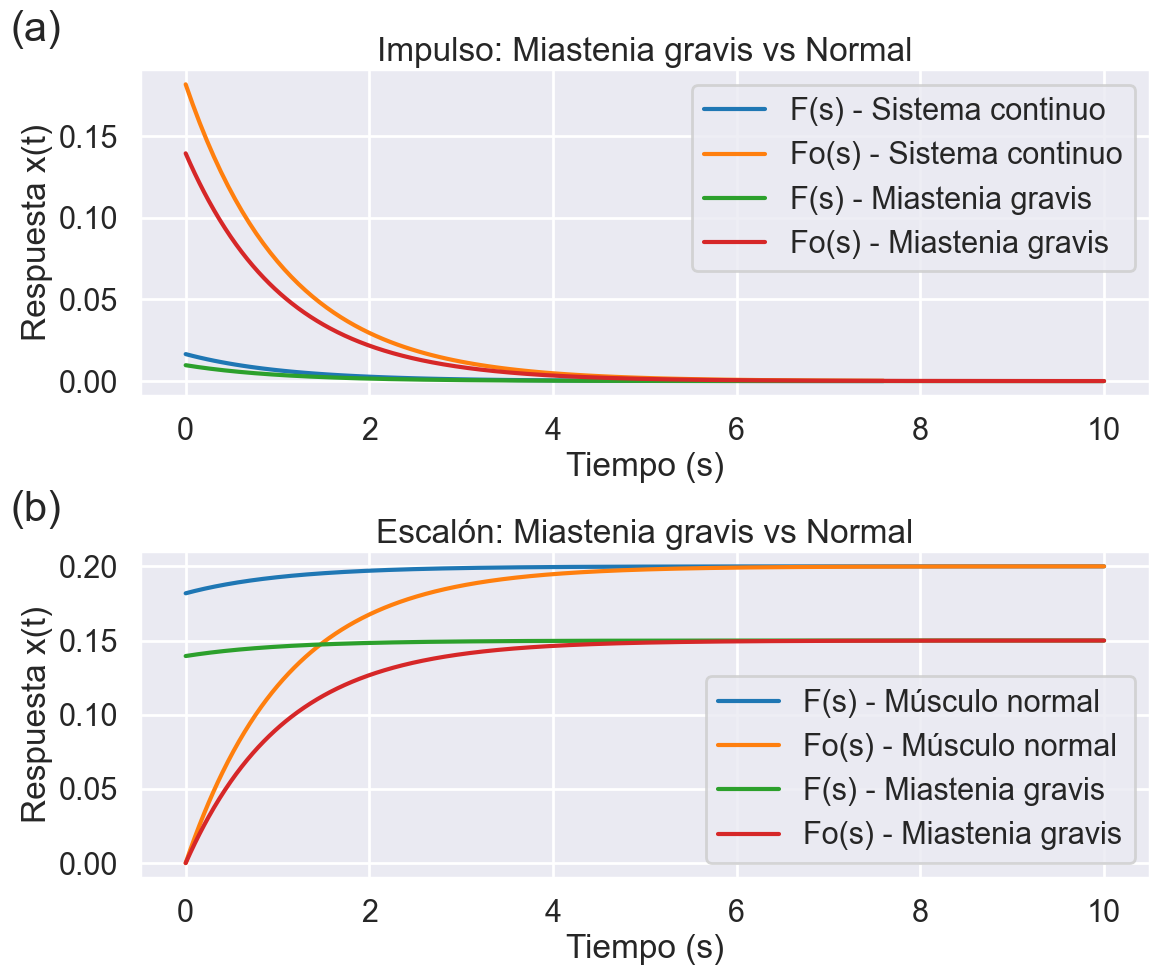

In [25]:
t = np.linspace(0, 10, 1000)

# ===== RESPUESTAS =====
# Impulso
y1_m,  t1_m  = impulse(G1_m, T=t)
y2_m,  t2_m  = impulse(G2_m, T=t)

# Escalón
y1s,   t1s   = step(G1,   T=t)
y2s,   t2s   = step(G2,   T=t)
y1s_m, t1s_m = step(G1_m, T=t)
y2s_m, t2s_m = step(G2_m, T=t)

# ===== SUBPLOTS =====
fig, ax = plt.subplots(2, 1, figsize=(12, 10))

# --- IMPULSO ---
ax[0].plot(t_imp_s,  y_imp_s,  color='#1f77b4', label="F(s) - Sistema continuo")
ax[0].plot(t2_imp_s, y2_imp_s, color='#ff7f0e', label="Fo(s) - Sistema continuo")
ax[0].plot(t1_m, y1_m, color='#2ca02c', label="F(s) - Miastenia gravis")
ax[0].plot(t2_m, y2_m, color='#d62728', label="Fo(s) - Miastenia gravis")
ax[0].set_title("Impulso: Miastenia gravis vs Normal")
ax[0].set_xlabel("Tiempo (s)")
ax[0].set_ylabel("Respuesta x(t)")
ax[0].legend()

# --- ESCALÓN ---
ax[1].plot(t1s,   y1s,   color='#1f77b4', label="F(s) - Músculo normal")
ax[1].plot(t2s,   y2s,   color='#ff7f0e', label="Fo(s) - Músculo normal")
ax[1].plot(t1s_m, y1s_m, color='#2ca02c', label="F(s) - Miastenia gravis")
ax[1].plot(t2s_m, y2s_m, color='#d62728', label="Fo(s) - Miastenia gravis")
ax[1].set_title("Escalón: Miastenia gravis vs Normal")
ax[1].set_xlabel("Tiempo (s)")
ax[1].set_ylabel("Respuesta x(t)")
ax[1].legend()
# etiquetas (a) y (b) fuera del gráfico
fig.text(0.02, 0.96, "(a)", fontsize=30)
fig.text(0.02, 0.48, "(b)", fontsize=30)
plt.tight_layout()
plt.show()

### Distrofia Muscular 

In [9]:
# Parámetros del sistema para simulación de Distrofia Muscular

R_dm = 1.0        # aumento de viscosidad (≈100% mayor que el valor normal 0.5)
Cs_dm = 1.0       # reducción de elasticidad estructural (≈50% menor que 2)
Cp_dm = 0.10      # reducción de capacidad contráctil (≈50% menor que 0.2)

num_G1_dm = [Cs_dm * Cp_dm * R_dm, Cp_dm]
den_G1_dm = [R_dm * Cs_dm + R_dm * Cp_dm, 1]

# G2(s) = (Cp) / ((R*Cs + R*Cp)*s + 1)
num_G2_dm = [Cp]
den_G2_dm = [R_dm * Cs_dm + R_dm * Cp_dm, 1]

G1_dm = tf(num_G1_dm, den_G1_dm)
G2_dm = tf(num_G2_dm, den_G2_dm)

print("G1_distrofia(s) =", G1_dm)
print(" ")
print("G2_distrofia(s) =", G2_dm)

G1_distrofia(s) = <TransferFunction>: sys[32]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

  0.1 s + 0.1
  -----------
   1.1 s + 1
 
G2_distrofia(s) = <TransferFunction>: sys[33]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

    0.15
  ---------
  1.1 s + 1


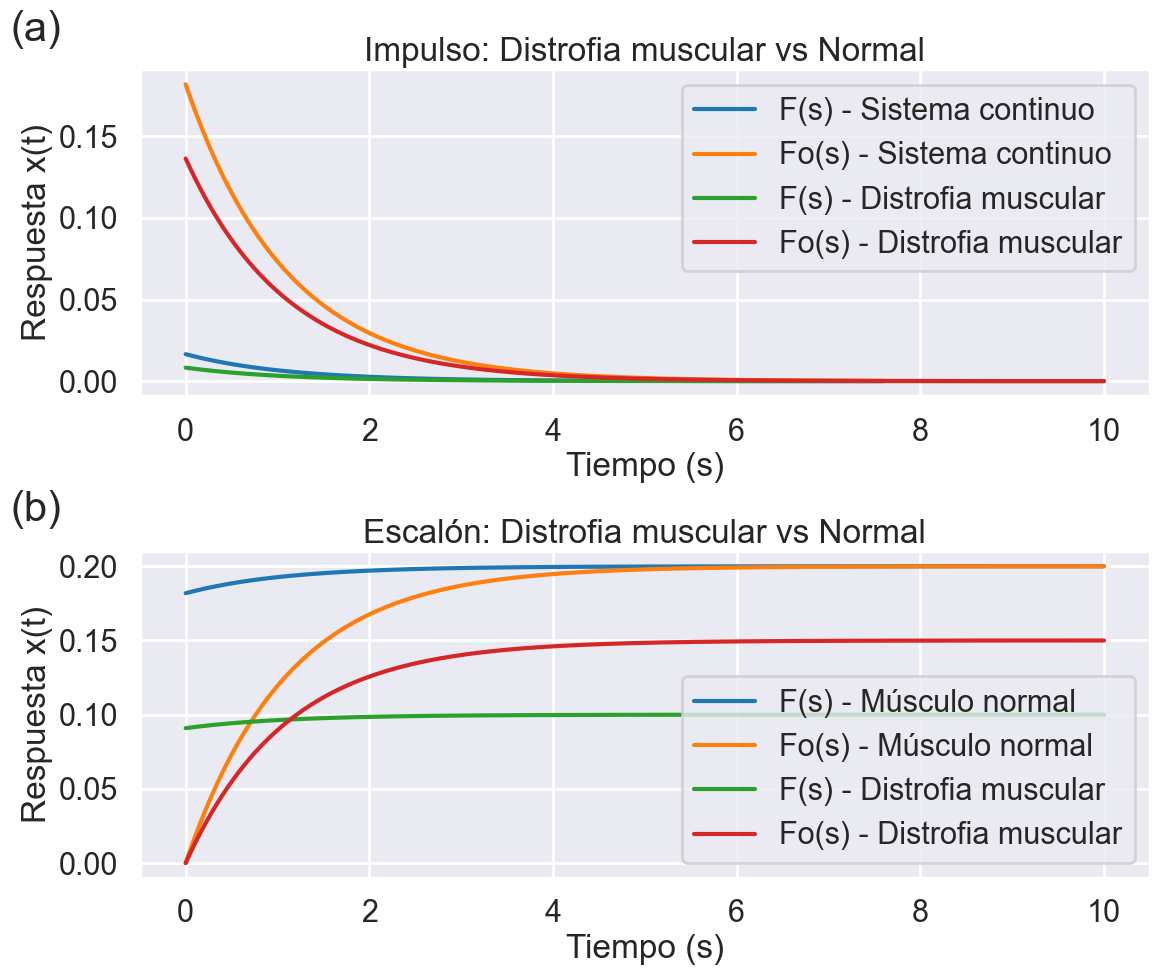

In [26]:
t_dm = np.linspace(0, 10, 1000)

# ===== RESPUESTAS =====
# Impulso
y1_dm,  t1_dm  = impulse(G1_dm, T=t_dm)
y2_dm,  t2_dm  = impulse(G2_dm, T=t_dm)

# Escalón
y1s,    t1s    = step(G1,    T=t_dm)
y2s,    t2s    = step(G2,    T=t_dm)
y1s_dm, t1s_dm = step(G1_dm, T=t_dm)
y2s_dm, t2s_dm = step(G2_dm, T=t_dm)

# ===== SUBPLOTS =====
fig, ax = plt.subplots(2, 1, figsize=(12, 10))

# --- IMPULSO ---
ax[0].plot(t_imp_s,  y_imp_s,  color='#1f77b4', label="F(s) - Sistema continuo")
ax[0].plot(t2_imp_s, y2_imp_s, color='#ff7f0e', label="Fo(s) - Sistema continuo")
ax[0].plot(t1_dm, y1_dm, color='#2ca02c', label="F(s) - Distrofia muscular")
ax[0].plot(t2_dm, y2_dm, color='#d62728', label="Fo(s) - Distrofia muscular")
ax[0].set_title("Impulso: Distrofia muscular vs Normal")
ax[0].set_xlabel("Tiempo (s)")
ax[0].set_ylabel("Respuesta x(t)")
ax[0].legend()

# --- ESCALÓN ---
ax[1].plot(t1s,    y1s,    color='#1f77b4', label="F(s) - Músculo normal")
ax[1].plot(t2s,    y2s,    color='#ff7f0e', label="Fo(s) - Músculo normal")
ax[1].plot(t1s_dm, y1s_dm, color='#2ca02c', label="F(s) - Distrofia muscular")
ax[1].plot(t2s_dm, y2s_dm, color='#d62728', label="Fo(s) - Distrofia muscular")
ax[1].set_title("Escalón: Distrofia muscular vs Normal")
ax[1].set_xlabel("Tiempo (s)")
ax[1].set_ylabel("Respuesta x(t)")
ax[1].legend()

# etiquetas (a) y (b) fuera del gráfico
fig.text(0.02, 0.96, "(a)", fontsize=30)
fig.text(0.02, 0.48, "(b)", fontsize=30)

plt.tight_layout()
plt.show()

### Punto 5

*Considere que la siguiente función de transferencia modela la dinámica simplificada del sistema de control de flujo de un ventilador mecánico.*

 *•	La entrada representa la señal de control aplicada a la válvula proporcional del sistema.*
 
 *•	La salida corresponde al flujo de aire suministrado al paciente.* 
 
 *•	a y b corresponde al último digito de la cedula de cada integrante del grupo y c es la suma de estos últimos dígitos: Reemplazando a = 0, b= 4 y c = 4 se tiene que: $$G(s) = \frac{4}{(s+2)^2}$$*

*a)	Determine los polos y ceros del sistema. Simule y grafique la respuesta al escalón unitario, impulso y rampa unitaria en lazo abierto y en lazo cerrado*

In [11]:
numP5 = [0, 4] #as + b
denP5 = [1, 4, 4] #s^2 + bs + c

G_5 = tf(numP5, denP5)

print("G (s) =", G_5)

G (s) = <TransferFunction>: sys[40]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

        4
  -------------
  s^2 + 4 s + 4


Diagrama de polos y ceros

Polos del sistema: [-2.+0.j -2.+0.j]
Ceros del sistema: []

El sistema es estable


c:\Users\USUARIO\anaconda3\Lib\site-packages\control\pzmap.py:327: FutureWarning: pole_zero_plot() return value of poles, zeros is deprecated; use pole_zero_map()
  warnings.warn(


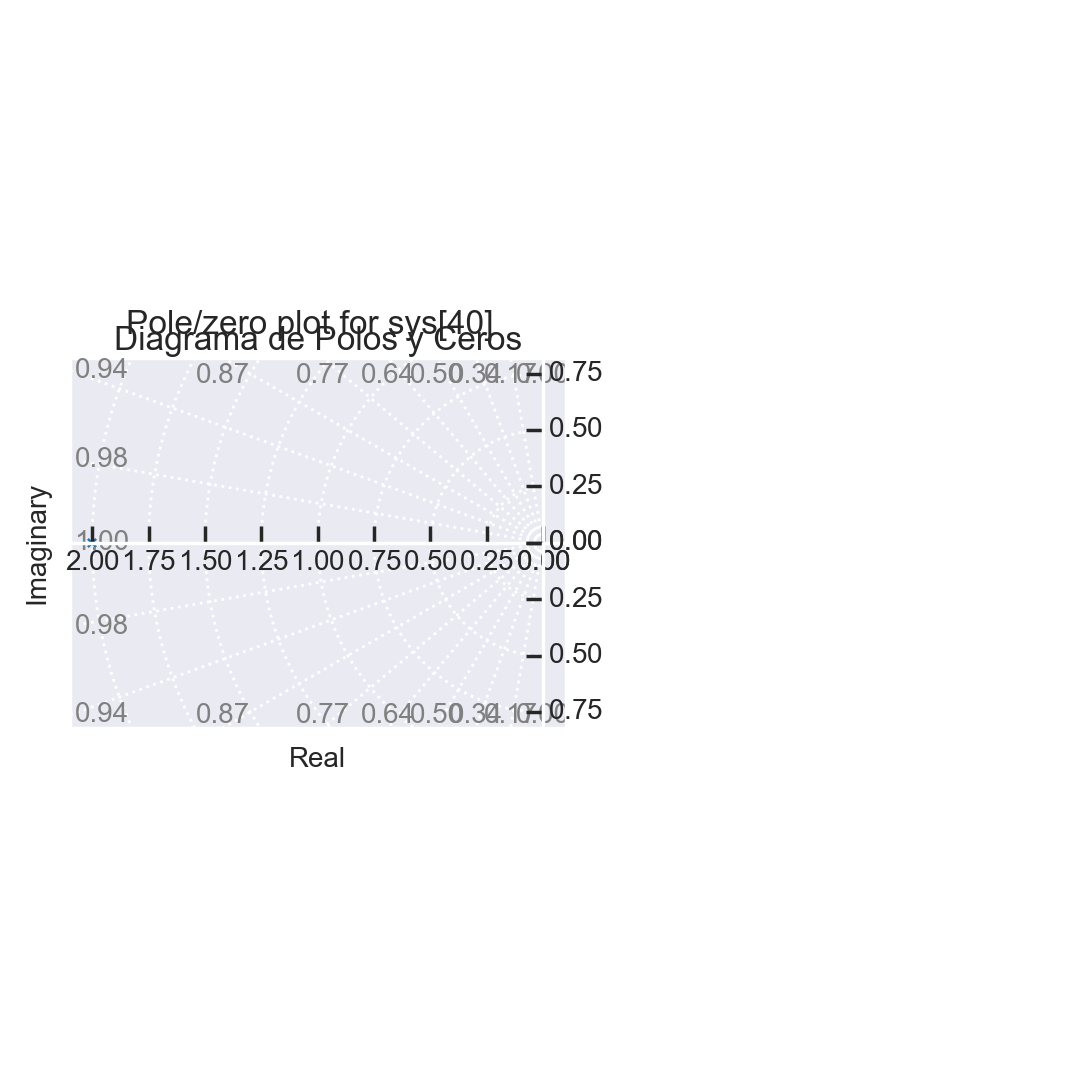

In [12]:
polos = pole(G_5)
ceros = zero(G_5)

print("Polos del sistema:", polos)
print("Ceros del sistema:", ceros)

# estabilidad
if np.all(np.real(polos) < 0):
    print("\nEl sistema es estable")
else:
    print("\nEl sistema es inestable")

# Diagrama de polos y ceros
plt.figure()
pzmap(G_5, plot=True, grid=True)
plt.title("Diagrama de Polos y Ceros")
plt.show()

Respuesta señales básicas en lazo abierto y cerrado

c:\Users\USUARIO\anaconda3\Lib\site-packages\control\timeresp.py:1082: UserWarning: return_x specified for a transfer function system. Internal conversion to state space used; results may meaningless.
  warnings.warn(


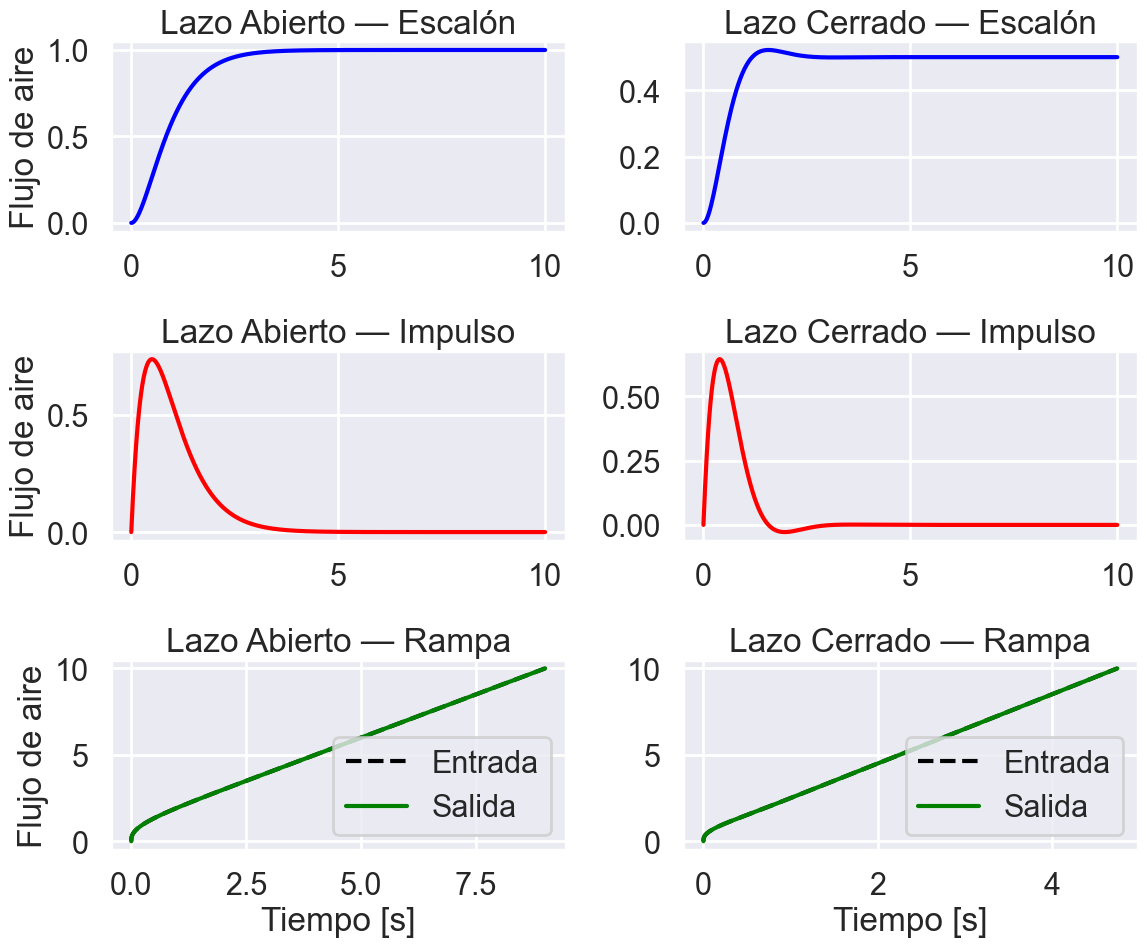

In [13]:
t = np.linspace(0, 10, 1000)

# Realimentación
G_lc = feedback(G_5, 1)

fig, axs = plt.subplots(3, 2, figsize=(12,10))

#Escalón

# Lazo abierto
y_step_la, t_step_la = step(G_5, T=t)
axs[0,0].plot(t_step_la, y_step_la, 'b')
axs[0,0].set_title("Lazo Abierto — Escalón")
axs[0,0].set_ylabel("Flujo de aire")
axs[0,0].grid(True)

# Lazo cerrado
y_step_lc, t_step_lc = step(G_lc, T=t)
axs[0,1].plot(t_step_lc, y_step_lc, 'b')
axs[0,1].set_title("Lazo Cerrado — Escalón")
axs[0,1].grid(True)

#Impulso

# Lazo abierto
y_imp_la, t_imp_la = impulse(G_5, T=t)
axs[1,0].plot(t_imp_la, y_imp_la, 'r')
axs[1,0].set_title("Lazo Abierto — Impulso")
axs[1,0].set_ylabel("Flujo de aire")
axs[1,0].grid(True)

# Lazo cerrado
y_imp_lc, t_imp_lc = impulse(G_lc, T=t)
axs[1,1].plot(t_imp_lc, y_imp_lc, 'r')
axs[1,1].set_title("Lazo Cerrado — Impulso")
axs[1,1].grid(True)

#Rampa

u_ramp = t

# Lazo abierto
t_ramp_la, y_ramp_la, _ = lsim(G_5, U=u_ramp, T=t)
axs[2,0].plot(t_ramp_la, u_ramp, 'k--', label="Entrada")
axs[2,0].plot(t_ramp_la, y_ramp_la, 'g', label="Salida")
axs[2,0].set_title("Lazo Abierto — Rampa")
axs[2,0].set_xlabel("Tiempo [s]")
axs[2,0].set_ylabel("Flujo de aire")
axs[2,0].legend()
axs[2,0].grid(True)

# Lazo cerrado
t_ramp_lc, y_ramp_lc, _ = lsim(G_lc, U=u_ramp, T=t)
axs[2,1].plot(t_ramp_lc, u_ramp, 'k--', label="Entrada")
axs[2,1].plot(t_ramp_lc, y_ramp_lc, 'g', label="Salida")
axs[2,1].set_title("Lazo Cerrado — Rampa")
axs[2,1].set_xlabel("Tiempo [s]")
axs[2,1].legend()
axs[2,1].grid(True)

plt.tight_layout()
plt.show()

*b)	Obtenga la función de transferencia equivalente en el dominio discreto (Z) para diferentes tiempos de muestreo: T=0.05, 0.1, 0.5, 1seg*

In [14]:
tiempos_muestreo = [0.05, 0.1, 0.5, 1.0]
Gz_dict = {}

for Ts in tiempos_muestreo:
    Gz = c2d(G_5, Ts, method='zoh') #se obtiene G en el dominio discreto
    print("\nSistema Discreto (ZOH):")
    Gz_dict[Ts] = Gz
    print(Gz)


Sistema Discreto (ZOH):
<TransferFunction>: sys[40]$sampled
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']
dt = 0.05

  0.004679 z + 0.004377
  ---------------------
  z^2 - 1.81 z + 0.8187

Sistema Discreto (ZOH):
<TransferFunction>: sys[40]$sampled
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']
dt = 0.1

   0.01752 z + 0.01534
  ----------------------
  z^2 - 1.637 z + 0.6703

Sistema Discreto (ZOH):
<TransferFunction>: sys[40]$sampled
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']
dt = 0.5

     0.2642 z + 0.1353
  -----------------------
  z^2 - 0.7358 z + 0.1353

Sistema Discreto (ZOH):
<TransferFunction>: sys[40]$sampled
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']
dt = 1.0

      0.594 z + 0.1537
  ------------------------
  z^2 - 0.2707 z + 0.01832


*c)	Para cada sistema discreto obtenido, simule y grafique la respuesta al escalón unitario, rampa y al impulso unitario en lazo abierto y en lazo cerrado*

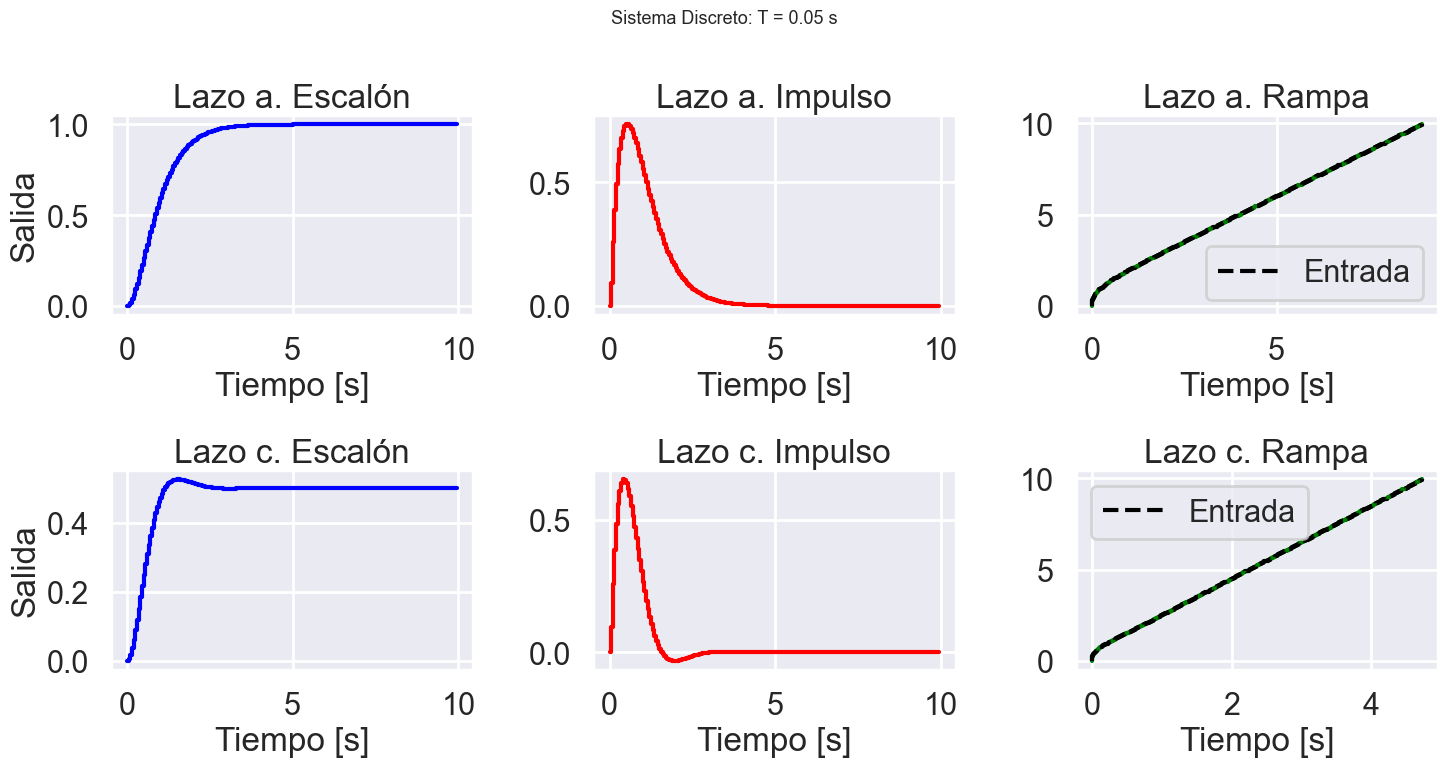

In [15]:

Ts = 0.05
Gz    = Gz_dict[Ts]
Gz_cl = feedback(Gz, 1)
t_d   = np.arange(0, 10, Ts)
u_r   = t_d   # para la rampa

y_s_la, t_s_la = step(Gz,    T=t_d)
y_s_lc, t_s_lc = step(Gz_cl, T=t_d)
y_i_la, t_i_la = impulse(Gz,    T=t_d)
y_i_lc, t_i_lc = impulse(Gz_cl, T=t_d)
t_r_la, y_r_la, _ = lsim(Gz,    U=u_r, T=t_d)
t_r_lc, y_r_lc, _ = lsim(Gz_cl, U=u_r, T=t_d)

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle(f"Sistema Discreto: T = {Ts} s", fontsize=13)

axes[0,0].step(t_s_la, y_s_la, 'b', where='post'); axes[0,0].set_title("Lazo a. Escalón"); axes[0,0].grid(True); axes[0,0].set_xlabel("Tiempo [s]"); axes[0,0].set_ylabel("Salida")
axes[0,1].step(t_i_la, y_i_la, 'r', where='post'); axes[0,1].set_title("Lazo a. Impulso"); axes[0,1].grid(True); axes[0,1].set_xlabel("Tiempo [s]")
axes[0,2].step(t_r_la, y_r_la, 'g', where='post'); axes[0,2].step(t_r_la, u_r, 'k--', where='post', label='Entrada'); axes[0,2].set_title("Lazo a. Rampa"); axes[0,2].grid(True); axes[0,2].set_xlabel("Tiempo [s]"); axes[0,2].legend()
axes[1,0].step(t_s_lc, y_s_lc, 'b', where='post'); axes[1,0].set_title("Lazo c. Escalón"); axes[1,0].grid(True); axes[1,0].set_xlabel("Tiempo [s]"); axes[1,0].set_ylabel("Salida")
axes[1,1].step(t_i_lc, y_i_lc, 'r', where='post'); axes[1,1].set_title("Lazo c. Impulso"); axes[1,1].grid(True); axes[1,1].set_xlabel("Tiempo [s]")
axes[1,2].step(t_r_lc, y_r_lc, 'g', where='post'); axes[1,2].step(t_r_lc, u_r, 'k--', where='post', label='Entrada'); axes[1,2].set_title("Lazo c. Rampa"); axes[1,2].grid(True); axes[1,2].set_xlabel("Tiempo [s]"); axes[1,2].legend()

plt.tight_layout()
plt.show()

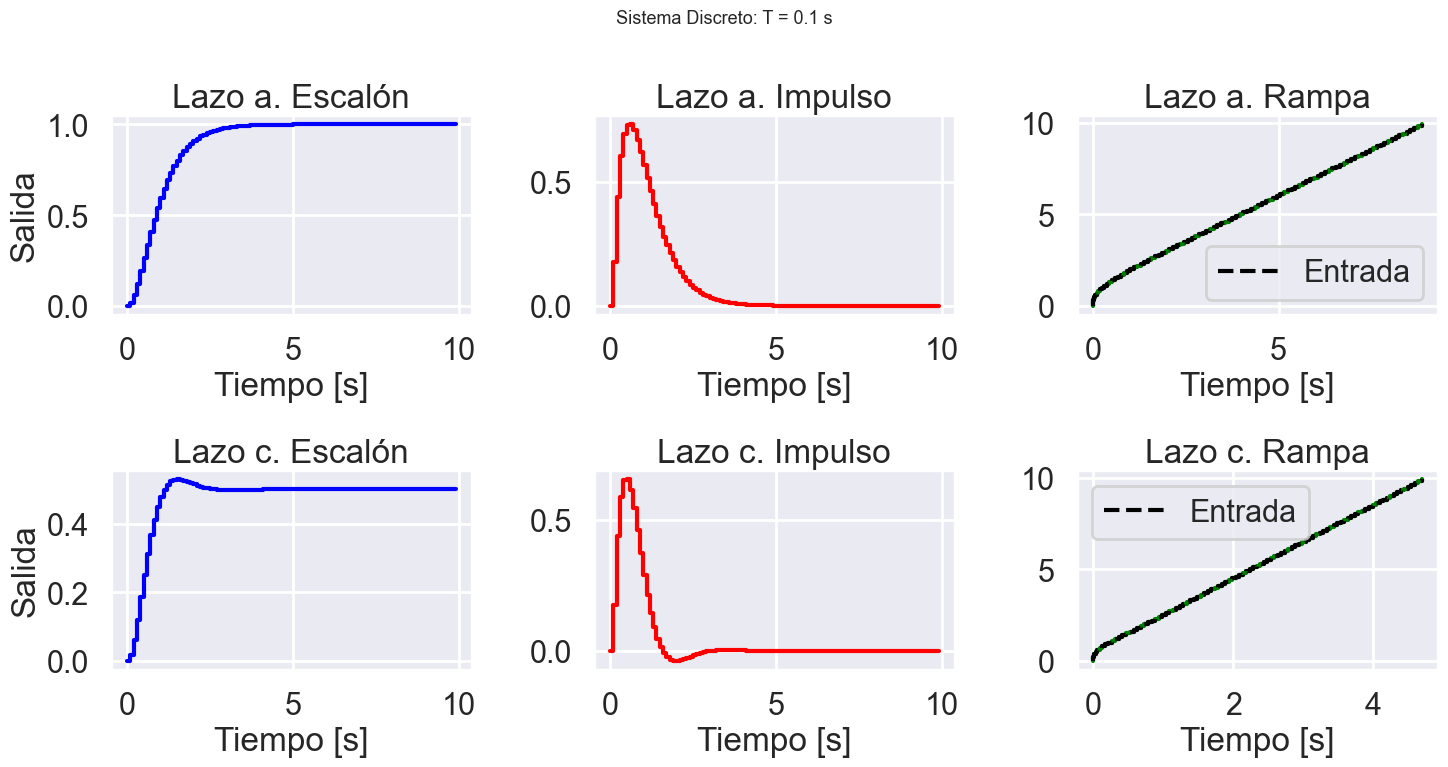

In [16]:
Ts = 0.1
Gz    = Gz_dict[Ts]
Gz_cl = feedback(Gz, 1)
t_d   = np.arange(0, 10, Ts)
u_r   = t_d

y_s_la, t_s_la = step(Gz,    T=t_d)
y_s_lc, t_s_lc = step(Gz_cl, T=t_d)
y_i_la, t_i_la = impulse(Gz,    T=t_d)
y_i_lc, t_i_lc = impulse(Gz_cl, T=t_d)
t_r_la, y_r_la, _ = lsim(Gz,    U=u_r, T=t_d)
t_r_lc, y_r_lc, _ = lsim(Gz_cl, U=u_r, T=t_d)

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle(f"Sistema Discreto: T = {Ts} s", fontsize=13)

axes[0,0].step(t_s_la, y_s_la, 'b', where='post'); axes[0,0].set_title("Lazo a. Escalón"); axes[0,0].grid(True); axes[0,0].set_xlabel("Tiempo [s]"); axes[0,0].set_ylabel("Salida")
axes[0,1].step(t_i_la, y_i_la, 'r', where='post'); axes[0,1].set_title("Lazo a. Impulso"); axes[0,1].grid(True); axes[0,1].set_xlabel("Tiempo [s]")
axes[0,2].step(t_r_la, y_r_la, 'g', where='post'); axes[0,2].step(t_r_la, u_r, 'k--', where='post', label='Entrada'); axes[0,2].set_title("Lazo a. Rampa"); axes[0,2].grid(True); axes[0,2].set_xlabel("Tiempo [s]"); axes[0,2].legend()
axes[1,0].step(t_s_lc, y_s_lc, 'b', where='post'); axes[1,0].set_title("Lazo c. Escalón"); axes[1,0].grid(True); axes[1,0].set_xlabel("Tiempo [s]"); axes[1,0].set_ylabel("Salida")
axes[1,1].step(t_i_lc, y_i_lc, 'r', where='post'); axes[1,1].set_title("Lazo c. Impulso"); axes[1,1].grid(True); axes[1,1].set_xlabel("Tiempo [s]")
axes[1,2].step(t_r_lc, y_r_lc, 'g', where='post'); axes[1,2].step(t_r_lc, u_r, 'k--', where='post', label='Entrada'); axes[1,2].set_title("Lazo c. Rampa"); axes[1,2].grid(True); axes[1,2].set_xlabel("Tiempo [s]"); axes[1,2].legend()
plt.tight_layout()
plt.show()

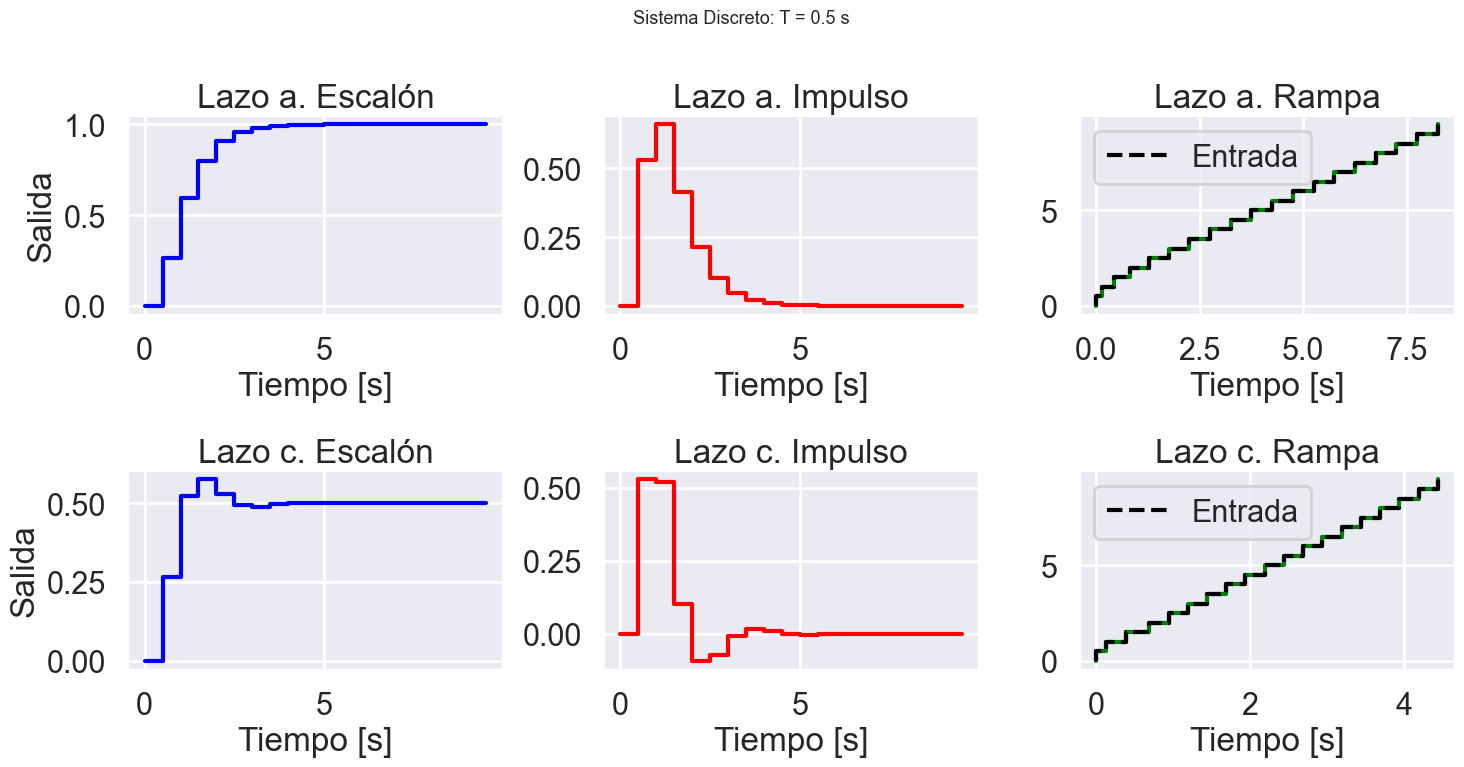

In [17]:
Ts = 0.5
Gz    = Gz_dict[Ts]
Gz_cl = feedback(Gz, 1)
t_d   = np.arange(0, 10, Ts)
u_r   = t_d

y_s_la, t_s_la = step(Gz,    T=t_d)
y_s_lc, t_s_lc = step(Gz_cl, T=t_d)
y_i_la, t_i_la = impulse(Gz,    T=t_d)
y_i_lc, t_i_lc = impulse(Gz_cl, T=t_d)
t_r_la, y_r_la, _ = lsim(Gz,    U=u_r, T=t_d)
t_r_lc, y_r_lc, _ = lsim(Gz_cl, U=u_r, T=t_d)

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle(f"Sistema Discreto: T = {Ts} s", fontsize=13)

axes[0,0].step(t_s_la, y_s_la, 'b', where='post'); axes[0,0].set_title("Lazo a. Escalón"); axes[0,0].grid(True); axes[0,0].set_xlabel("Tiempo [s]"); axes[0,0].set_ylabel("Salida")
axes[0,1].step(t_i_la, y_i_la, 'r', where='post'); axes[0,1].set_title("Lazo a. Impulso"); axes[0,1].grid(True); axes[0,1].set_xlabel("Tiempo [s]")
axes[0,2].step(t_r_la, y_r_la, 'g', where='post'); axes[0,2].step(t_r_la, u_r, 'k--', where='post', label='Entrada'); axes[0,2].set_title("Lazo a. Rampa"); axes[0,2].grid(True); axes[0,2].set_xlabel("Tiempo [s]"); axes[0,2].legend()
axes[1,0].step(t_s_lc, y_s_lc, 'b', where='post'); axes[1,0].set_title("Lazo c. Escalón"); axes[1,0].grid(True); axes[1,0].set_xlabel("Tiempo [s]"); axes[1,0].set_ylabel("Salida")
axes[1,1].step(t_i_lc, y_i_lc, 'r', where='post'); axes[1,1].set_title("Lazo c. Impulso"); axes[1,1].grid(True); axes[1,1].set_xlabel("Tiempo [s]")
axes[1,2].step(t_r_lc, y_r_lc, 'g', where='post'); axes[1,2].step(t_r_lc, u_r, 'k--', where='post', label='Entrada'); axes[1,2].set_title("Lazo c. Rampa"); axes[1,2].grid(True); axes[1,2].set_xlabel("Tiempo [s]"); axes[1,2].legend()
plt.tight_layout()
plt.show()


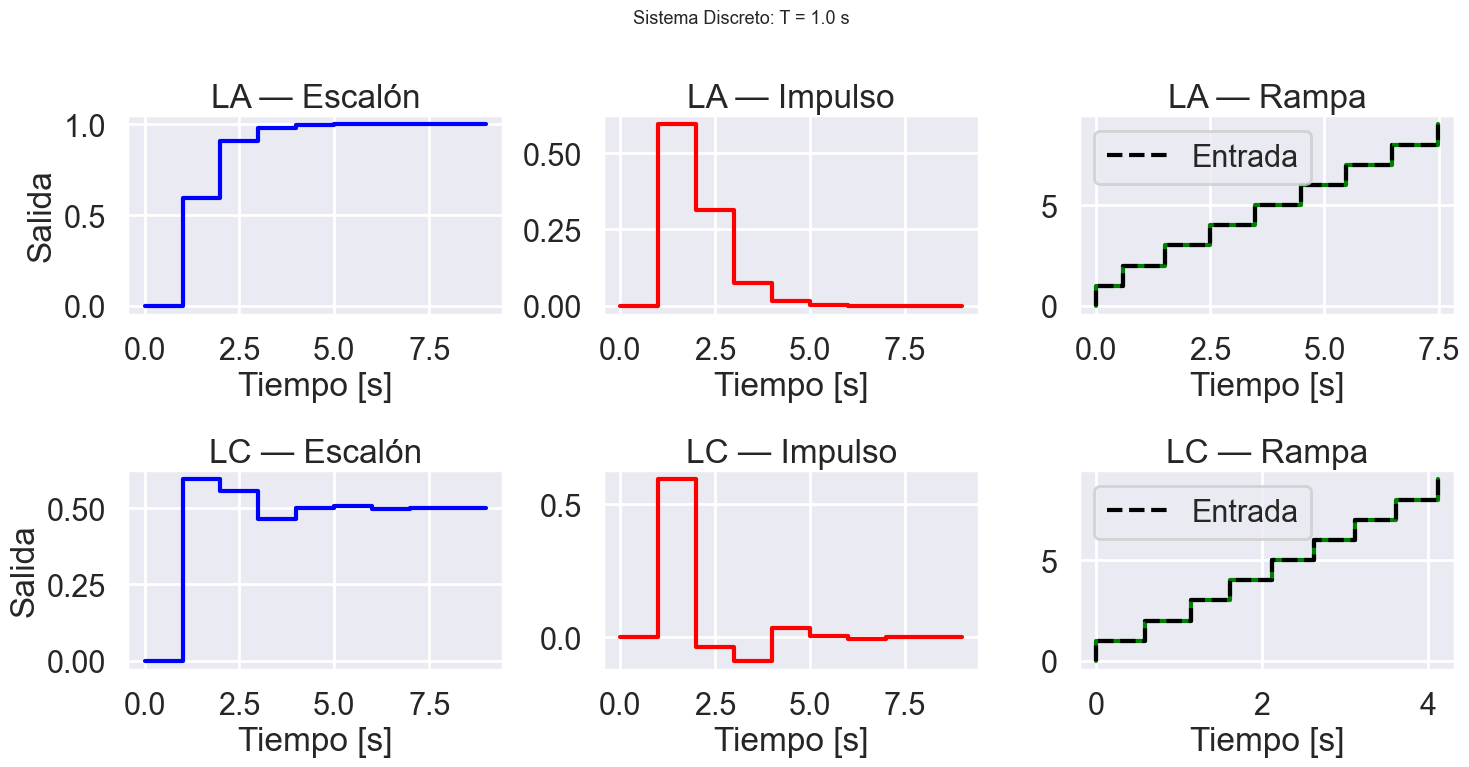

In [18]:
Ts = 1.0
Gz    = Gz_dict[Ts]
Gz_cl = feedback(Gz, 1)
t_d   = np.arange(0, 10, Ts)
u_r   = t_d

y_s_la, t_s_la = step(Gz,    T=t_d)
y_s_lc, t_s_lc = step(Gz_cl, T=t_d)
y_i_la, t_i_la = impulse(Gz,    T=t_d)
y_i_lc, t_i_lc = impulse(Gz_cl, T=t_d)
t_r_la, y_r_la, _ = lsim(Gz,    U=u_r, T=t_d)
t_r_lc, y_r_lc, _ = lsim(Gz_cl, U=u_r, T=t_d)

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle(f"Sistema Discreto: T = {Ts} s", fontsize=13)

axes[0,0].step(t_s_la, y_s_la, 'b', where='post'); axes[0,0].set_title("LA — Escalón"); axes[0,0].grid(True); axes[0,0].set_xlabel("Tiempo [s]"); axes[0,0].set_ylabel("Salida")
axes[0,1].step(t_i_la, y_i_la, 'r', where='post'); axes[0,1].set_title("LA — Impulso"); axes[0,1].grid(True); axes[0,1].set_xlabel("Tiempo [s]")
axes[0,2].step(t_r_la, y_r_la, 'g', where='post'); axes[0,2].step(t_r_la, u_r, 'k--', where='post', label='Entrada'); axes[0,2].set_title("LA — Rampa"); axes[0,2].grid(True); axes[0,2].set_xlabel("Tiempo [s]"); axes[0,2].legend()
axes[1,0].step(t_s_lc, y_s_lc, 'b', where='post'); axes[1,0].set_title("LC — Escalón"); axes[1,0].grid(True); axes[1,0].set_xlabel("Tiempo [s]"); axes[1,0].set_ylabel("Salida")
axes[1,1].step(t_i_lc, y_i_lc, 'r', where='post'); axes[1,1].set_title("LC — Impulso"); axes[1,1].grid(True); axes[1,1].set_xlabel("Tiempo [s]")
axes[1,2].step(t_r_lc, y_r_lc, 'g', where='post'); axes[1,2].step(t_r_lc, u_r, 'k--', where='post', label='Entrada'); axes[1,2].set_title("LC — Rampa"); axes[1,2].grid(True); axes[1,2].set_xlabel("Tiempo [s]"); axes[1,2].legend()

plt.tight_layout()
plt.show()

Valor de T que mejor representa el sistema discreto mediante el cálculo de MSE

In [19]:
# Referencia continua
t = np.linspace(0, 10, 1000)
y_cont_la, t_cont_la = step(G_5, T=t)

# MSE por tiempo de muestreo
print(f"{'T (s)':<10} {'MSE':<20}")

for Ts in tiempos_muestreo:
    t_d = np.arange(0, 10, Ts)
    y_d, t_d_s = step(Gz_dict[Ts], T=t_d)
    y_ref = np.interp(t_d_s, t_cont_la, y_cont_la)
    mse = np.mean((y_d - y_ref)**2)
    print(f"{Ts:<10} {mse:<20.6e}")

T (s)      MSE                 
0.05       9.159721e-13        
0.1        9.157186e-13        
0.5        8.482156e-13        
1.0        9.364850e-13        
